In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

In [5]:
data = np.array([
30,31,32,33,34,
35,36,37,38,39,
40,41,42,43,44,
45,46,47,48,49,
50,51,52,53,54,
55,56,57,58,59
])

In [6]:
data = data.reshape(-1,1)
print(data.shape)

(30, 1)


In [7]:
data

array([[30],
       [31],
       [32],
       [33],
       [34],
       [35],
       [36],
       [37],
       [38],
       [39],
       [40],
       [41],
       [42],
       [43],
       [44],
       [45],
       [46],
       [47],
       [48],
       [49],
       [50],
       [51],
       [52],
       [53],
       [54],
       [55],
       [56],
       [57],
       [58],
       [59]])

In [8]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [9]:
scaled_data

array([[0.        ],
       [0.03448276],
       [0.06896552],
       [0.10344828],
       [0.13793103],
       [0.17241379],
       [0.20689655],
       [0.24137931],
       [0.27586207],
       [0.31034483],
       [0.34482759],
       [0.37931034],
       [0.4137931 ],
       [0.44827586],
       [0.48275862],
       [0.51724138],
       [0.55172414],
       [0.5862069 ],
       [0.62068966],
       [0.65517241],
       [0.68965517],
       [0.72413793],
       [0.75862069],
       [0.79310345],
       [0.82758621],
       [0.86206897],
       [0.89655172],
       [0.93103448],
       [0.96551724],
       [1.        ]])

In [10]:
def create_dataset(dataset, time_step):
    X = []
    y = []

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])

    return np.array(X), np.array(y)

In [11]:
time_step = 5
X,y = create_dataset(scaled_data,time_step)

In [12]:
print(X.shape)

(25, 5, 1)


In [13]:
print(y.shape)

(25, 1)


In [14]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [15]:
lstm_model = Sequential()

lstm_model.add(LSTM(50,input_shape=(time_step,1)))

lstm_model.add(Dense(1))

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
lstm_model.compile(optimizer='adam',
                   loss='mse'
                   )

In [17]:
history_lstm = lstm_model.fit(X_train,y_train,epochs=100,batch_size=4,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.2631 - val_loss: 0.6797
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1888 - val_loss: 0.5129
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1346 - val_loss: 0.3503
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0788 - val_loss: 0.2057
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0391 - val_loss: 0.0848
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0088 - val_loss: 0.0162
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0041 - val_loss: 7.4927e-05
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0093 - val_loss: 7.8742e-04
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0078 - val_loss: 8.0249e-04
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0038 - val_loss: 0.0083
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0032 - val_loss: 0.0162
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0

In [18]:
lstm_predicction = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


In [21]:
actual = scaler.inverse_transform(y_test)

predicted = scaler.inverse_transform(lstm_predicction)

In [26]:
print(actual)

[[55.]
 [56.]
 [57.]
 [58.]
 [59.]]


In [24]:
print(predicted)

[[55.338406]
 [56.412018]
 [57.487057]
 [58.562695]
 [59.638077]]


In [27]:
last_sequence = np.array([55,56,57,58,59]).reshape(-1,1)

last_sequence = scaler.transform(last_sequence)

last_sequence = last_sequence.reshape(1,5,1)

next_value = lstm_model.predict(last_sequence)

next_value = scaler.inverse_transform(next_value)

print(next_value)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
[[60.712395]]


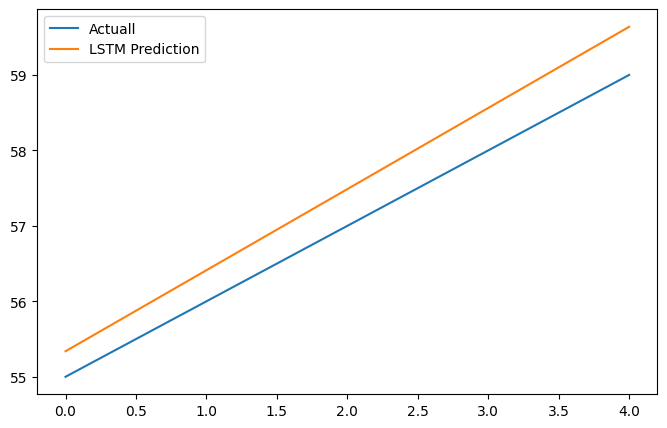

In [22]:
plt.figure(figsize=(8,5))
plt.plot(actual,label='Actuall')
plt.plot(predicted,label='LSTM Prediction')
plt.legend()
plt.show()

# Project 2

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,GRU,Dense

In [4]:
data = np.array([
30,31,32,33,34,
35,36,37,38,39,
40,41,42,43,44,
45,46,47,48,49,
50,51,52,53,54,
55,56,57,58,59
])

In [5]:
data = data.reshape(-1,1)
print(data.shape)

(30, 1)


In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [7]:
def create_dataset(dataset,time_step):
    X = []
    y = []

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X),np.array(y)

In [8]:
time_step = 5 
X,y = create_dataset(scaled_data,time_step)

print(X.shape)
print(y.shape)

(25, 5, 1)
(25, 1)


In [9]:
train_size = int(len(X)*0.8)

X_train,X_test = X[:train_size],X[train_size:]
y_train,y_test = y[:train_size],y[train_size:]

In [10]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, input_shape=(time_step,1)))
lstm_model.add(Dense(1))

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

In [14]:
history_lstm = lstm_model.fit(X_train,y_train,epochs=100,batch_size=4,validation_data=(X_test,y_test), verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.3191 - val_loss: 0.8045
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2135 - val_loss: 0.5754
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1457 - val_loss: 0.3724
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0838 - val_loss: 0.2066
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0390 - val_loss: 0.0851
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 0.0203
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0051 - val_loss: 6.1740e-04
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0088 - val_loss: 2.7210e-04
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0086 - val_loss: 4.5957e-04
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0048 - val_loss: 0.0057
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0030 - val_loss: 0.0131
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0

In [15]:
lstm_prediction = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


In [16]:
actual = scaler.inverse_transform(y_test)
predicted = scaler.inverse_transform(lstm_prediction)

In [ ]:
last_sequence = np.array([55,56,57,58,59]).reshape(-1,1)

last_sequence = scaler.transform(last_sequence)

last_sequence = last_sequence.reshape(1,5,1)

next_value = lstm_model.predict(last_sequence)

next_value = scaler.inverse_transform(next_value)

print(next_value)

In [18]:
last_seq = np.array([55,56,57,58,59]).reshape(-1,1)
last_seq = scaler.transform(last_seq)
last_seq = last_seq.reshape(1,5,1)

next_val = lstm_model.predict(last_seq)
next_val = scaler.inverse_transform(next_val)
print(next_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[60.805397]]


# Project 3

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input,LSTM,Dense

In [2]:
daily_sales = np.array([100, 105, 110, 120, 125, 130, 140, 145, 150, 160,
               165, 170, 180, 185, 190, 200, 205, 210, 220, 225])

In [3]:
data = daily_sales.reshape(-1,1)
print(data.shape)

(20, 1)


In [5]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [15]:

def create_sequence(dataset, time_step):
    X = []
    y = []
    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X), np.array(y)

In [16]:
len(data_scaled)

20

In [18]:
time_step = 5
X,y = create_sequence(data_scaled,time_step=time_step)

print(X.shape)
print(y.shape)

(15, 5, 1)
(15, 1)


In [19]:
split = int(len(X)*0.8)
X_train,X_test = X[split:],X[:split]
y_train,y_test = y[split:],y[:split]

In [22]:
lstm_model = Sequential()
lstm_model.add(LSTM(50,input_shape=(time_step,1)))
lstm_model.add(Dense(1))

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
lstm_model.compile(optimizer='adam',loss='mse')

In [26]:
lstm_model.fit(X_train,y_train,epochs=10,batch_size=4,validation_data=(X_test,y_test),verbose=1)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0496 - val_loss: 0.0094
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0334 - val_loss: 0.0054
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0204 - val_loss: 0.0026
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0107 - val_loss: 0.0011
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0043 - val_loss: 7.8560e-04
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 9.0464e-04 - val_loss: 0.0015
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 2.7163e-04 - val_loss: 0.0030
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0019 - val_loss: 0.0051
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0053 - val_loss: 0.0074
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0096 - val_loss: 0.0098


In [27]:
lstm_prediction = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step


In [28]:
actual = scaler.inverse_transform(y_test)
predicted = scaler.inverse_transform(lstm_prediction)

In [34]:
import numpy as np

# Last 5 values (original scale)
last_seq = np.array([190, 200, 205, 210, 220]).reshape(-1, 1)

# Scale the values
last_seq = scaler.transform(last_seq)

# Reshape for LSTM: (samples, timesteps, features)
last_seq = last_seq.reshape(1, 5, 1)

# Predict the next scaled value
next_scaled = lstm_model.predict(last_seq, verbose=0)

# Convert prediction back to original scale
next_value = scaler.inverse_transform(next_scaled)

print("Next predicted value:", next_value[0][0])

Next predicted value: 240.10161


# project 4


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf 
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Input,Dense,LSTM

In [37]:
data = np.array([
    1,2,3,4,5,6,7,8,9,10
])

In [38]:
data = data.reshape(-1,1)
data.shape

(10, 1)

In [39]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [40]:
def create_dataset(dataset, time_step):
    X=[]
    y=[]
    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X),np.array(y)

In [41]:
time_step=4
X,y = create_dataset(data_scaled,time_step)


In [42]:
X.shape

(6, 4, 1)

In [43]:
y.shape

(6, 1)

In [44]:
split = int(len(X)*0.8)
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

In [45]:
lstm = Sequential()
lstm.add(LSTM(50,input_shape=(time_step,1)))
lstm.add(Dense(1))

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
lstm.compile(optimizer='adam',loss='mse')

In [47]:
lstm.fit(X_train,y_train,epochs=500,batch_size=4,validation_data=(X_test,y_test),verbose=1)

Epoch 1/500


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.3571 - val_loss: 0.7799
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.3423 - val_loss: 0.7470
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.3278 - val_loss: 0.7147
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.3136 - val_loss: 0.6828
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.2995 - val_loss: 0.6514
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.2857 - val_loss: 0.6205
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.2721 - val_loss: 0.5900
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.2586 - val_loss: 0.5598
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.2453 - val_loss: 0.5300
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2321 - val_loss: 0.5006
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.2191 - val_loss: 0.4715
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.2062 - val_loss: 0.4427
Epo

In [48]:
prediction = lstm.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


In [49]:
actual = scaler.inverse_transform(data_scaled)
predicted = scaler.inverse_transform(prediction)

In [50]:
last_seq = np.array([7,8,9,10]).reshape(-1,1)

last_seq = scaler.transform(last_seq)

last_seq = last_seq.reshape(1,4,1)

next_val = lstm.predict(last_seq)
next_val = scaler.inverse_transform(next_val)
print(next_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
[[11.0935755]]


# project 5

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import LSTM,Dense,SimpleRNN
from sklearn.preprocessing import MinMaxScaler


In [21]:
data = np.array([1,2,3,4,5,6,7,8,9,10])

In [22]:
data = data.reshape(-1,1)

In [23]:
data.shape

(10, 1)

In [24]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [25]:
def create_dataset(dataset,time_step):
    X=[]
    y=[]

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X),np.array(y)

In [26]:
seq_len = 4
X,y = create_dataset(data_scaled,seq_len)

In [27]:
X.shape

(6, 4, 1)

In [28]:
y.shape

(6, 1)

In [51]:
split = int(len(X)*0.8)
X_train,X_test = X[:split],X[split:]
y_train,y_test = y[:split],y[split:]

In [52]:
model = Sequential([
    LSTM(50,input_shape=(seq_len,1)),
    Dense(1)
])

c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.compile(optimizer='adam',loss = 'mse')

In [54]:
model.fit(X_train,y_train,epochs=500,batch_size=2,validation_data=(X_test,y_test),verbose=1)

Epoch 1/500


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - loss: 0.5007 - val_loss: 1.1498
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.4658 - val_loss: 1.0676
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.4322 - val_loss: 0.9899
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.3993 - val_loss: 0.9166
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.3656 - val_loss: 0.8474
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.3399 - val_loss: 0.7805
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3102 - val_loss: 0.7169
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.2797 - val_loss: 0.6565
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.2570 - val_loss: 0.5967
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2301 - val_loss: 0.5386
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2056 - val_loss: 0.4815
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.1831 - val_loss: 0.4252


In [55]:
pred =  model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


In [56]:
actual  = scaler.inverse_transform(y_test)
prediction = scaler.inverse_transform(pred)

In [57]:
last_seq = np.array([7,8,9,10]).reshape(-1,1)

last_seq = scaler.transform(last_seq)

last_seq = last_seq.reshape(1,4,1)

next_val = model.predict(last_seq)

next_val = scaler.inverse_transform(next_val)

print(next_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
[[11.371436]]


# Project 6

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import LSTM,Dense,SimpleRNN
from sklearn.preprocessing import MinMaxScaler


In [2]:
data = np.array([
    1,2,3,4,5,6,7,8,9,10
]).reshape(-1,1)

data.shape

(10, 1)

In [3]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [4]:
def create_dataset(dataset,time_step):
    X = []
    y = []

    for i in range(len(dataset)-time_step):
        X.append(dataset[i:i+time_step])
        y.append(dataset[i+time_step])
    return np.array(X),np.array(y)

In [5]:
seq_len=4
X,y = create_dataset(data_scaled,seq_len)

In [6]:
X.shape

(6, 4, 1)

In [7]:
split = int(len(X)*0.8)

X_train,X_test,y_train,y_test = X[:split],X[split:],y[:split],y[split:]

In [8]:
model = Sequential([
    LSTM(50,input_shape=(seq_len,1)),
    Dense(1)
])


c:\Users\MINA\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(optimizer='adam',loss='mse')

In [19]:
model.fit(X_train,y_train,epochs=500,batch_size=2,validation_data=(X_test,y_test),verbose=1)

Epoch 1/500
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 7.7565e-06

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 1.7553e-05 - val_loss: 7.6272e-06
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 1.6898e-05 - val_loss: 6.4665e-06
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 1.6155e-05 - val_loss: 5.1920e-06
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 1.5847e-05 - val_loss: 3.1296e-06
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.4632e-05 - val_loss: 2.2160e-06
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.4234e-05 - val_loss: 1.8419e-06
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.3827e-05 - val_loss: 1.2906e-06
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1.2906e-05 - val_loss: 1.1850e-06
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.2361e-05 - val_loss: 1.1758e-06
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1.2101e-05 - val_loss: 1.2379e-06
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 1.1546e-05 - val_loss: 1.2996e

In [20]:
pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [21]:
actual = scaler.inverse_transform(y_test)
prediction = scaler.inverse_transform(pred)

In [22]:
last_seq = np.array([7,8,9,10]).reshape(-1,1)

last_seq = scaler.transform(last_seq)

last_seq = last_seq.reshape(1,4,1)

next_val = model.predict(last_seq)

next_val = scaler.inverse_transform(next_val)

print(next_val)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
[[11.137782]]
